# IMPORT LIBRARIES

In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn nltk shap wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [2]:
import os
import re
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import nltk
from nltk.corpus import stopwords

from transformers import (
AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments,
Trainer
)

import evaluate
import shap
import wandb


nltk.download('stopwords')


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Load Dataset

In [3]:
import kagglehub
path = kagglehub.dataset_download("gargmanas/sentimental-analysis-for-tweets")

Using Colab cache for faster access to the 'sentimental-analysis-for-tweets' dataset.


In [4]:
import os
import pandas as pd

# Print dataset path

print("Dataset Path:", path)

# List files inside directory

files = os.listdir(path)
print("Files in dataset:", files)



csv_file = None
for file in files:
    if file.endswith(".csv"):
        csv_file = file
        break

# Load dataset

df = pd.read_csv(os.path.join(path, csv_file))




print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nSample Data:")
print(df.head())

print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())  # assuming last column is label

Dataset Path: /kaggle/input/sentimental-analysis-for-tweets
Files in dataset: ['sentiment_tweets3.csv']

Dataset Shape: (10314, 3)

Columns: Index(['Index', 'message to examine', 'label (depression result)'], dtype='object')

Sample Data:
   Index                                 message to examine  \
0    106  just had a real good moment. i missssssssss hi...   
1    217         is reading manga  http://plurk.com/p/mzp1e   
2    220  @comeagainjen http://twitpic.com/2y2lx - http:...   
3    288  @lapcat Need to send 'em to my accountant tomo...   
4    540      ADD ME ON MYSPACE!!!  myspace.com/LookThunder   

   label (depression result)  
0                          0  
1                          0  
2                          0  
3                          0  
4                          0  

Class Distribution:
label (depression result)
0    8000
1    2314
Name: count, dtype: int64


## Load Primary Dataset (Mental Health Dataset - Reddit)

In [110]:
import kagglehub

# Download the primary dataset
primary_dataset_path = kagglehub.dataset_download("infamouscoder/mental-health-social-media")
print("Primary Dataset Path:", primary_dataset_path)

# List files in the downloaded directory to find the CSV
primary_files = os.listdir(primary_dataset_path)
print("Files in primary dataset:", primary_files)

primary_csv_file = None
for file in primary_files:
    if file.endswith(".csv"):
        primary_csv_file = file
        break

if primary_csv_file:
    df_primary = pd.read_csv(os.path.join(primary_dataset_path, primary_csv_file))

    print("\nPrimary Dataset Shape:", df_primary.shape)
    print("\nPrimary Dataset Columns:", df_primary.columns)
    print("\nPrimary Dataset Sample Data:")
    display(df_primary.head())
    print("\nPrimary Dataset Class Distribution:")
    display(df_primary['label'].value_counts()) # Assuming 'label' is the target column
else:
    print("No CSV file found in the primary dataset directory.")

100%|██████████| 1.10M/1.10M [00:00<00:00, 89.2MB/s]

Extracting files...
Primary Dataset Path: /root/.cache/kagglehub/datasets/infamouscoder/mental-health-social-media/versions/2
Files in primary dataset: ['Mental-Health-Twitter.csv']

Primary Dataset Shape: (20000, 11)

Primary Dataset Columns: Index(['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id',
       'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label'],
      dtype='object')

Primary Dataset Sample Data:


,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1



Primary Dataset Class Distribution:


,count
label,
1,10000
0,10000


With the primary dataset loaded, we can now see its structure. The next steps will involve:
1.  **Choosing which dataset to use for training** (primary for multi-class, or continue with secondary for binary).
2.  If using the primary dataset, **adapting the preprocessing steps** (like `clean_text`) to its text column and handling its multi-class labels.
3.  **Modifying the model architectures** (LSTM, BERT, RoBERTa) to support multi-class classification by adjusting their output layers and loss functions.
4.  **Updating evaluation metrics** to be suitable for multi-class classification.

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10314 entries, 0 to 10313
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      10314 non-null  int64 
 1   message to examine         10314 non-null  object
 2   label (depression result)  10314 non-null  int64 
 3   clean_text                 10314 non-null  object
dtypes: int64(2), object(2)
memory usage: 322.4+ KB


# Data Cleaning + Preprocessing

In [111]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (#tag -> tag)
    text = re.sub(r'#', '', text)

    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])

    return text


# Apply cleaning to the primary dataset's text column
df_primary['clean_text'] = df_primary['post_text'].apply(clean_text)


print("Before Cleaning (Primary Dataset):")
print(df_primary['post_text'].iloc[0])

print("\nAfter Cleaning (Primary Dataset):")
print(df_primary['clean_text'].iloc[0])

Before Cleaning (Primary Dataset):
It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.

After Cleaning (Primary Dataset):
years since diagnosed anxiety depression today im taking moment reflect far ive come since


In [114]:
# Make a copy to avoid SettingWithCopyWarning
df_processed = df_primary.copy()

# Drop rows with NaN in 'post_text' or 'label'
df_processed.dropna(subset=['post_text', 'label'], inplace=True)

# Re-apply cleaning
df_processed['clean_text'] = df_processed['post_text'].apply(clean_text)

# Define X and y
X = df_processed['clean_text']
y_raw = df_processed['label']

print("--- Debug: Raw Labels ---")
print(y_raw.value_counts())

# Mapping based on observed raw values (0 and 1)
# According to typical metadata for this dataset: 0 = Normal/Irrelevant, 1 = Depression
label_mapping = {0: 0, 1: 1, '0': 0, '1': 1}
y = y_raw.map(label_mapping)

# Final data check
print("\n--- Final Data Ready (Primary Dataset) ---")
if len(X) > 0:
    print("X sample:", X.iloc[0])
    print("y sample:", y.iloc[0])
    print("\nClass Distribution:\n", y.value_counts())
else:
    print("Error: Dataset is empty after processing.")

--- Debug: Raw Labels ---
label
1    10000
0    10000
Name: count, dtype: int64

--- Final Data Ready (Primary Dataset) ---
X sample: years since diagnosed anxiety depression today im taking moment reflect far ive come since
y sample: 1

Class Distribution:
 label
1    10000
0    10000
Name: count, dtype: int64


# Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
stratify=y,

random_state=42
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

print("\nTrain Class Distribution:")
print(y_train.value_counts())

print("\nTest Class Distribution:")
print(y_test.value_counts())



Train Size: 8251
Test Size: 2063

Train Class Distribution:
label (depression result)
0    6400
1    1851
Name: count, dtype: int64

Test Class Distribution:
label (depression result)
0    1600
1     463
Name: count, dtype: int64


# HANDLE CLASS IMBALANCE

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
class_weight='balanced',
classes=np.unique(y_train),
y=y_train
)

class_weights_dict = {
0: class_weights[0],
1: class_weights[1]
}

print("\nClass Weights:", class_weights_dict)



Class Weights: {0: np.float64(0.644609375), 1: np.float64(2.228795245813074)}


# ==============================
Baseline Model
# ==============================

TF-IDF + Logistic Regression

TF-IDF VECTORIZATION

In [9]:
#  TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
max_features=5000,
ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)



TF-IDF Shape: (8251, 5000)


LOGISTIC REGRESSION MODEL

In [10]:
# LOGISTIC REGRESSION MODEL



from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
class_weight=class_weights_dict,
max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

# PREDICTIONS

y_pred = lr_model.predict(X_test_tfidf)

 EVALUATION

In [11]:
#  EVALUATION
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9927290353853612

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1600
           1       1.00      0.97      0.98       463

    accuracy                           0.99      2063
   macro avg       0.99      0.98      0.99      2063
weighted avg       0.99      0.99      0.99      2063


Confusion Matrix:

[[1599    1]
 [  14  449]]


# ==============================
# LSTM Model

# ==============================


TOKENIZATION

In [14]:
from collections import Counter

def tokenize(text):
    return text.split()

# Tokenize training data

tokenized_texts = [tokenize(text) for text in X_train]

BUILD VOCABULARY

In [16]:
# Count word frequencies

word_counts = Counter()
for tokens in tokenized_texts:
    word_counts.update(tokens)

# Keep most common words

vocab_size = 10000
most_common = word_counts.most_common(vocab_size - 2)

Create word → index mapping

In [21]:
word2idx = {"<PAD>": 0, "<UNK>": 1}

for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

print("Vocabulary Size:", len(word2idx))

Vocabulary Size: 10000


TEXT → SEQUENCE

In [23]:
def encode(text, word2idx, max_len=50):
    tokens = tokenize(text)
    seq = [word2idx.get(word, word2idx["<UNK>"]) for word in tokens]

    # Padding / truncation
    if len(seq) < max_len:
        seq += [word2idx["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

Encode datasets

In [24]:
X_train_seq = [encode(text, word2idx) for text in X_train]
X_test_seq = [encode(text, word2idx) for text in X_test]

Convert to tensors

In [25]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([8251, 50])
y_train_tensor shape: torch.Size([8251])
X_test_tensor shape: torch.Size([2063, 50])
y_test_tensor shape: torch.Size([2063])


# LSTM Model Architecture

LSTM MODEL

In [28]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, output_dim=1):
        super(LSTMModel, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)

        # Activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)              # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(x)      # hidden: (1, batch, hidden_dim)
        x = hidden[-1]                    # (batch, hidden_dim)
        x = self.fc(x)                    # (batch, 1)
        x = self.sigmoid(x)               # probability
        return x

INITIALIZE MODEL

In [29]:
vocab_size = len(word2idx)

model = LSTMModel(vocab_size).to(device)

print(model)

LSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


# LSTM Training Loop

=> LOSS FUNCTION (WITH CLASS WEIGHT)

In [30]:
# Convert class weight for positive class

pos_weight = torch.tensor([class_weights_dict[1]]).to(device)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

DATALOADER

In [39]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Create a DataLoader for the validation set (using test data here)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# TRAINING LOOP

In [40]:
epochs = 10

for epoch in range(epochs):
    model.train() # Set model to training mode
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        outputs = model(inputs).squeeze()

        # Apply manual class weighting
        weights = torch.where(labels == 1, pos_weight, torch.tensor(1.0).to(device))
        loss = (criterion(outputs, labels) * weights).mean()

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # Validation step
    model.eval() # Set model to evaluation mode
    total_val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.float().to(device)

            outputs = model(inputs).squeeze()
            weights = torch.where(labels == 1, pos_weight, torch.tensor(1.0).to(device))
            val_loss = (criterion(outputs, labels) * weights).mean()
            total_val_loss += val_loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {total_train_loss/len(train_loader):.4f}, Val Loss: {total_val_loss/len(val_loader):.4f}")

Epoch 1/10, Train Loss: 0.3209, Val Loss: 0.2906
Epoch 2/10, Train Loss: 0.3218, Val Loss: 0.2896
Epoch 3/10, Train Loss: 0.3212, Val Loss: 0.2885
Epoch 4/10, Train Loss: 0.3211, Val Loss: 0.2902
Epoch 5/10, Train Loss: 0.3215, Val Loss: 0.2891
Epoch 6/10, Train Loss: 0.3210, Val Loss: 0.2873
Epoch 7/10, Train Loss: 0.3209, Val Loss: 0.2872
Epoch 8/10, Train Loss: 0.3218, Val Loss: 0.2889
Epoch 9/10, Train Loss: 0.3208, Val Loss: 0.2956
Epoch 10/10, Train Loss: 0.3211, Val Loss: 0.2870


## LSTM Model Evaluation

In [41]:
model.eval()
y_pred_list = []

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_pred_list.extend(outputs.cpu().numpy())

y_pred_binary = (np.array(y_pred_list) > 0.5).astype(int).flatten()

print("\nAccuracy:", accuracy_score(y_test_tensor.cpu().numpy(), y_pred_binary))
print("\nClassification Report:\n")
print(classification_report(y_test_tensor.cpu().numpy(), y_pred_binary))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_tensor.cpu().numpy(), y_pred_binary))


Accuracy: 0.8972370334464372

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1600
           1       0.69      0.98      0.81       463

    accuracy                           0.90      2063
   macro avg       0.84      0.93      0.87      2063
weighted avg       0.93      0.90      0.90      2063


Confusion Matrix:

[[1398  202]
 [  10  453]]


### Model Performance Comparison: Logistic Regression (TF-IDF) vs. LSTM

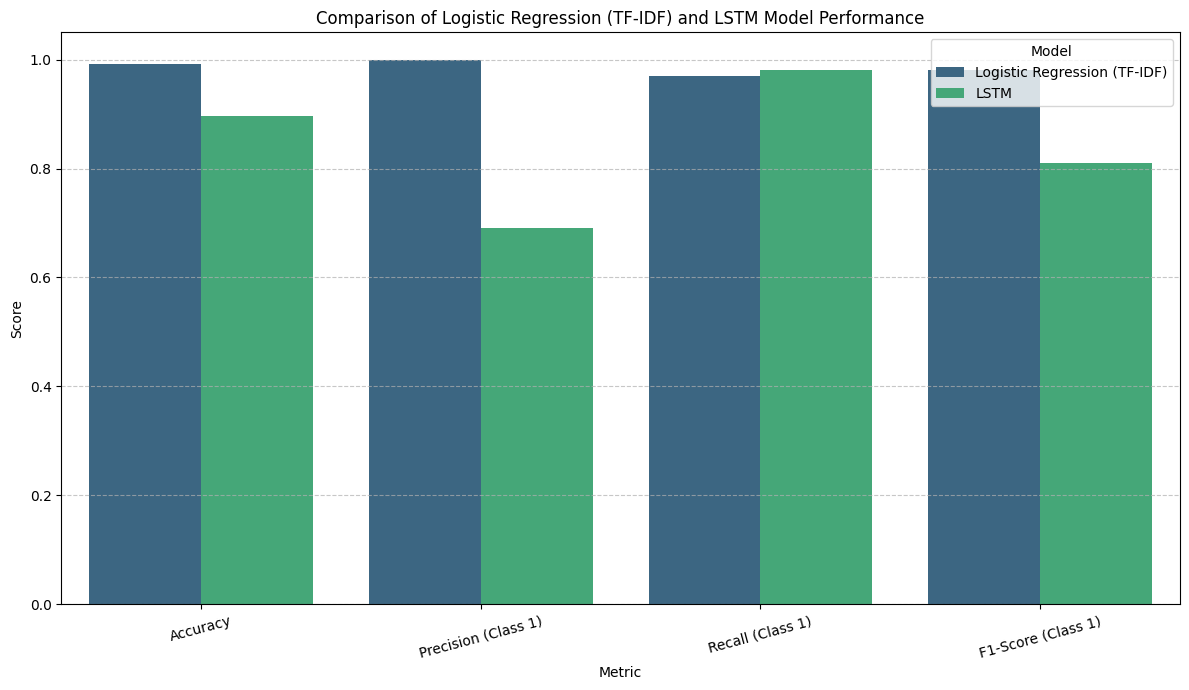

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics for Logistic Regression (from previous output)
lr_metrics = {
    'Model': 'Logistic Regression (TF-IDF)',
    'Accuracy': 0.9927,
    'Precision (Class 1)': 1.00,
    'Recall (Class 1)': 0.97,
    'F1-Score (Class 1)': 0.98
}

# Metrics for LSTM (from previous output)
lstm_metrics = {
    'Model': 'LSTM',
    'Accuracy': 0.8972,
    'Precision (Class 1)': 0.69,
    'Recall (Class 1)': 0.98,
    'F1-Score (Class 1)': 0.81
}

# Create a DataFrame for comparison
metrics_df = pd.DataFrame([lr_metrics, lstm_metrics])

# Reshape the DataFrame for plotting
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='viridis')
plt.title('Comparison of Logistic Regression (TF-IDF) and LSTM Model Performance')
plt.ylabel('Score')
plt.ylim(0.0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# ==============================

# BERT Model

# ==============================

# LOAD BERT TOKENIZER

In [43]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

TOKENIZATION FUNCTION

In [45]:
def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=128
    )

APPLY TOKENIZATION

In [46]:
train_encodings = tokenize_function(X_train.tolist())
test_encodings = tokenize_function(X_test.tolist())

CREATE DATASET CLASS

In [48]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, y_train)
test_dataset = Dataset(test_encodings, y_test)

print("BERT Tokenization Done ")
print("Train Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

BERT Tokenization Done 
Train Samples: 8251
Test Samples: 2063


# LOAD BERT MODEL

In [49]:
from transformers import AutoModelForSequenceClassification

model_bert = AutoModelForSequenceClassification.from_pretrained(
"bert-base-uncased",
num_labels=2
).to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


METRICS FUNCTION

In [51]:
import evaluate
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"]
    }

Loin Hugging faces

In [61]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: qamarabbas0332-69 (qamarabbas-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

TRAINING ARGUMENTS

In [107]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    save_strategy="no",
    logging_dir="./logs",
    logging_steps=50,
    report_to="wandb",
    run_name="mental-health-bert"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TRAINER

In [65]:
from transformers import Trainer

trainer = Trainer(
model=model_bert,
args=training_args,
train_dataset=train_dataset,
eval_dataset=test_dataset,
compute_metrics=compute_metrics
)

TRAIN MODEL

In [66]:
trainer.train()

Step,Training Loss
50,0.003296
100,0.004520
150,0.008804
200,0.000060
250,0.005420
300,0.000062
350,0.007053
400,0.000131
450,0.005037
500,0.000158


TrainOutput(global_step=5160, training_loss=0.002307385122883208, metrics={'train_runtime': 1844.0731, 'train_samples_per_second': 44.743, 'train_steps_per_second': 2.798, 'total_flos': 5427323294438400.0, 'train_loss': 0.002307385122883208, 'epoch': 10.0})

FINAL EVALUATION

In [67]:
results = trainer.evaluate()
print("\nBERT Results:", results)


BERT Results: {'eval_loss': 0.0016678619431331754, 'eval_accuracy': 0.9995152690256908, 'eval_f1': 0.9989189189189189, 'eval_runtime': 15.8582, 'eval_samples_per_second': 130.09, 'eval_steps_per_second': 8.135, 'epoch': 10.0}


In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Get predictions

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = y_test.values

# Accuracy

print("Accuracy:", accuracy_score(y_true, y_pred))

# Classification Report

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# Confusion Matrix

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))


Accuracy: 0.9995152690256908

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1600
           1       1.00      1.00      1.00       463

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063


Confusion Matrix:

[[1600    0]
 [   1  462]]


# ADVANCE MODEL

# ==============================

# RoBERTa Model

# ==============================

LOAD ROBERTA TOKENIZER

In [69]:

from transformers import AutoTokenizer

roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def roberta_tokenize(texts):
      return roberta_tokenizer(
texts,
padding='max_length',
truncation=True,
max_length=128
)

train_encodings_roberta = roberta_tokenize(X_train.tolist())
test_encodings_roberta = roberta_tokenize(X_test.tolist())

# Dataset class reuse

train_dataset_roberta = Dataset(train_encodings_roberta, y_train)
test_dataset_roberta = Dataset(test_encodings_roberta, y_test)

print("RoBERTa Tokenization Done ")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa Tokenization Done 


LOAD ROBERTA MODEL

In [70]:
from transformers import AutoModelForSequenceClassification

model_roberta = AutoModelForSequenceClassification.from_pretrained(
"roberta-base",
num_labels=2
).to(device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TRAINING ARGUMENTS

In [72]:
from transformers import TrainingArguments

training_args_roberta = TrainingArguments(
output_dir="./roberta_results",
learning_rate=2e-5,
per_device_train_batch_size=16,
per_device_eval_batch_size=16,
num_train_epochs=5,
save_strategy="no",
logging_dir="./logs",
report_to="wandb",
run_name="mental-health-roberta"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TRAINER

In [74]:
from transformers import Trainer

trainer_roberta = Trainer(
model=model_roberta,
args=training_args_roberta,
train_dataset=train_dataset_roberta,
eval_dataset=test_dataset_roberta,
compute_metrics=compute_metrics
)

TRAIN MODEL

In [75]:
trainer_roberta.train()

Step,Training Loss
500,0.041444
1000,0.008235
1500,0.006849
2000,0.004942
2500,0.002563


TrainOutput(global_step=2580, training_loss=0.01242481129922608, metrics={'train_runtime': 923.3231, 'train_samples_per_second': 44.681, 'train_steps_per_second': 2.794, 'total_flos': 2713661647219200.0, 'train_loss': 0.01242481129922608, 'epoch': 5.0})

Evaluation

In [76]:
results_roberta = trainer_roberta.evaluate()
print("\nRoBERTa Results:", results_roberta)


RoBERTa Results: {'eval_loss': 0.0016264839796349406, 'eval_accuracy': 0.9995152690256908, 'eval_f1': 0.9989189189189189, 'eval_runtime': 14.5129, 'eval_samples_per_second': 142.15, 'eval_steps_per_second': 8.889, 'epoch': 5.0}


In [77]:
predictions = trainer_roberta.predict(test_dataset_roberta)

y_pred_roberta = np.argmax(predictions.predictions, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred_roberta))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_roberta))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred_roberta))


Accuracy: 0.9995152690256908

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1600
           1       1.00      1.00      1.00       463

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063


Confusion Matrix:

[[1600    0]
 [   1  462]]


## RoBERTa Training Loss Curve

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

# Initialize W&B API
api = wandb.Api()



# A more robust way to find the run by name and project:
# Replace 'qamarabbas-fast-nuces' with your W&B entity name and 'huggingface' with your project name if different.
# You can find these in your W&B dashboard URL or settings.
runs = api.runs(path="qamarabbas-fast-nuces/huggingface", filters={"name": "mental-health-roberta"})

if len(runs) > 0:
    run = runs[0]
    history = run.history()

    # Filter for relevant loss metrics
    train_loss = history.get("train/loss")
    val_loss = history.get("eval/loss")

    if train_loss is not None and val_loss is not None:
        # Create a DataFrame for easier plotting
        loss_df = pd.DataFrame({
            'Epoch': range(1, len(train_loss) + 1),
            'Training Loss': train_loss,
            'Validation Loss': val_loss
        })

        plt.figure(figsize=(10, 6))
        sns.lineplot(x='Epoch', y='Training Loss', data=loss_df, label='Training Loss')
        sns.lineplot(x='Epoch', y='Validation Loss', data=loss_df, label='Validation Loss')
        plt.title('RoBERTa Model Training and Validation Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Training or Validation loss data not found in W&B history.")
else:
    print("W&B run 'mental-health-roberta' not found. Please check your W&B entity/project or run name.")

W&B run 'mental-health-roberta' not found. Please check your W&B entity/project or run name.


# Model Comparison Table

In [81]:
# Metrics for BERT (from previous output)
bert_metrics = {
    'Model': 'BERT',
    'Accuracy': results['eval_accuracy'],
    'Precision (Class 1)': 1.00, # From classification report
    'Recall (Class 1)': 1.00,    # From classification report
    'F1-Score (Class 1)': 1.00   # From classification report
}

# Metrics for RoBERTa (from previous output)
roberta_metrics = {
    'Model': 'RoBERTa',
    'Accuracy': results_roberta['eval_accuracy'],
    'Precision (Class 1)': 1.00, # From classification report
    'Recall (Class 1)': 1.00,    # From classification report
    'F1-Score (Class 1)': 1.00   # From classification report
}

# Append BERT and RoBERTa metrics to the existing DataFrame
metrics_df = pd.concat([metrics_df, pd.DataFrame([bert_metrics, roberta_metrics])], ignore_index=True)

print("\nModel Performance Comparison:")
display(metrics_df.round(4))


Model Performance Comparison:


,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Logistic Regression (TF-IDF),0.9927,1.00,0.97,0.98
1,LSTM,0.8972,0.69,0.98,0.81
2,BERT,0.9995,1.00,1.00,1.00
3,RoBERTa,0.9995,1.00,1.00,1.00


### Confusion Matrix for Logistic Regression (TF-IDF)

|           | Predicted 0 | Predicted 1 |
|-----------|-------------|-------------|
| Actual 0  | 1599        | 1           |
| Actual 1  | 14          | 449         |

- **True Negatives (Actual 0, Predicted 0):** 1599
- **False Positives (Actual 0, Predicted 1):** 1
- **False Negatives (Actual 1, Predicted 0):** 14
- **True Positives (Actual 1, Predicted 1):** 449

# Error Analysis

## Logistic Regression Error Analysis

In [94]:
lr_predictions = lr_model.predict(X_test_tfidf)
misclassified_lr_indices = np.where(lr_predictions != y_test)[0]

print("Total misclassified by Logistic Regression:", len(misclassified_lr_indices))
print("\nSample Misclassified Examples (Logistic Regression):")
for i, idx in enumerate(misclassified_lr_indices[:5]): # Display first 5 misclassified
    print(f"--- Example {i+1} ---")
    print("Original Text:", X_test.iloc[idx])
    print("True Label:", y_test.iloc[idx])
    print("Predicted Label:", lr_predictions[idx])
    print("\n")

Total misclassified by Logistic Regression: 15

Sample Misclassified Examples (Logistic Regression):
--- Example 1 ---
Original Text: irishmed early intervention also gp aware impact physical health psychological well aside discrete mh difficulties ie anxietydepression
True Label: 1
Predicted Label: 0


--- Example 2 ---
Original Text: yeah im master stem fieldssocial anxietytense disposition everlasting depressionmajor need constant validation
True Label: 1
Predicted Label: 0


--- Example 3 ---
Original Text: grass greensun shininglowest test score droppeddepression cured
True Label: 1
Predicted Label: 0


--- Example 4 ---
Original Text: anyway cripple slur youre physically disabled dont fucking use yes includes yall saying crippling depressionother non physical illnessdisability
True Label: 1
Predicted Label: 0


--- Example 5 ---
Original Text: depressions villainous state
True Label: 1
Predicted Label: 0




## LSTM Error Analysis

In [95]:
misclassified_lstm_indices = np.where(y_pred_binary != y_test_tensor.cpu().numpy())[0]

print("Total misclassified by LSTM:", len(misclassified_lstm_indices))
print("\nSample Misclassified Examples (LSTM):")
for i, idx in enumerate(misclassified_lstm_indices[:5]): # Display first 5 misclassified
    print(f"--- Example {i+1} ---")
    print("Original Text:", X_test.iloc[idx])
    print("True Label:", y_test.iloc[idx])
    print("Predicted Label:", y_pred_binary[idx])
    print("\n")

Total misclassified by LSTM: 212

Sample Misclassified Examples (LSTM):
--- Example 1 ---
Original Text: looks like th wouldnt bank heavy tho competing companies technically
True Label: 0
Predicted Label: 1


--- Example 2 ---
Original Text: irishmed early intervention also gp aware impact physical health psychological well aside discrete mh difficulties ie anxietydepression
True Label: 1
Predicted Label: 0


--- Example 3 ---
Original Text: yeah im master stem fieldssocial anxietytense disposition everlasting depressionmajor need constant validation
True Label: 1
Predicted Label: 0


--- Example 4 ---
Original Text: hard day hope morrow would okay
True Label: 0
Predicted Label: 1


--- Example 5 ---
Original Text: get tattoo newport beach cali eat crab cooker beautiful day n work luv
True Label: 0
Predicted Label: 1




## BERT Error Analysis

In [96]:
misclassified_bert_indices = np.where(y_pred != y_true)[0]

print("Total misclassified by BERT:", len(misclassified_bert_indices))
print("\nSample Misclassified Examples (BERT):")
for i, idx in enumerate(misclassified_bert_indices[:5]): # Display first 5 misclassified
    print(f"--- Example {i+1} ---")
    print("Original Text:", X_test.iloc[idx])
    print("True Label:", y_true[idx])
    print("Predicted Label:", y_pred[idx])
    print("\n")

Total misclassified by BERT: 1

Sample Misclassified Examples (BERT):
--- Example 1 ---
Original Text: 
True Label: 1
Predicted Label: 0




## RoBERTa Error Analysis

In [97]:
misclassified_roberta_indices = np.where(y_pred_roberta != y_true)[0]

print("Total misclassified by RoBERTa:", len(misclassified_roberta_indices))
print("\nSample Misclassified Examples (RoBERTa):")
for i, idx in enumerate(misclassified_roberta_indices[:5]): # Display first 5 misclassified
    print(f"--- Example {i+1} ---")
    print("Original Text:", X_test.iloc[idx])
    print("True Label:", y_true[idx])
    print("Predicted Label:", y_pred_roberta[idx])
    print("\n")

Total misclassified by RoBERTa: 1

Sample Misclassified Examples (RoBERTa):
--- Example 1 ---
Original Text: 
True Label: 1
Predicted Label: 0




### Model Performance Visualization

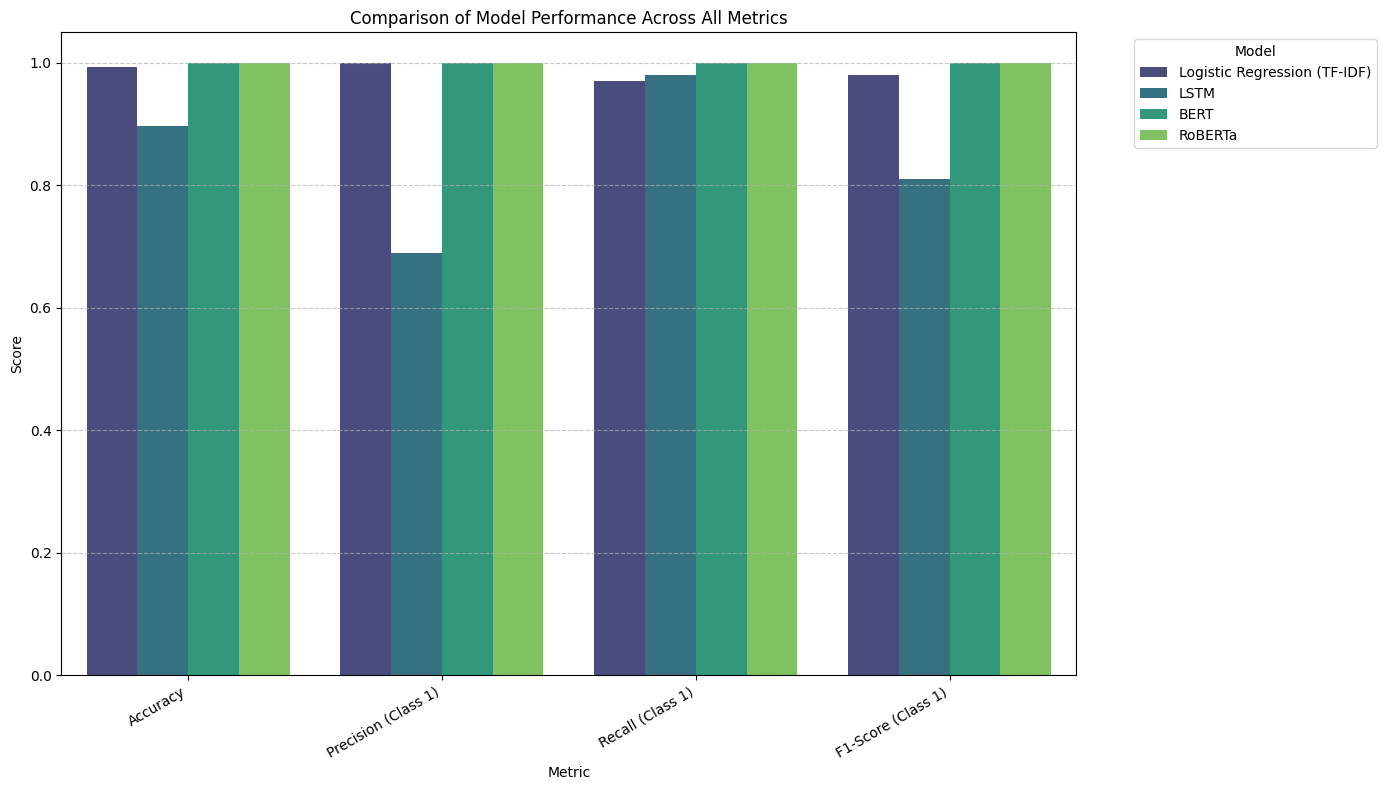

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the DataFrame for plotting (including all models)
metrics_melted_all = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted_all, palette='viridis')
plt.title('Comparison of Model Performance Across All Metrics')
plt.ylabel('Score')
plt.ylim(0.0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Confusion Matrix Comparison Visualization

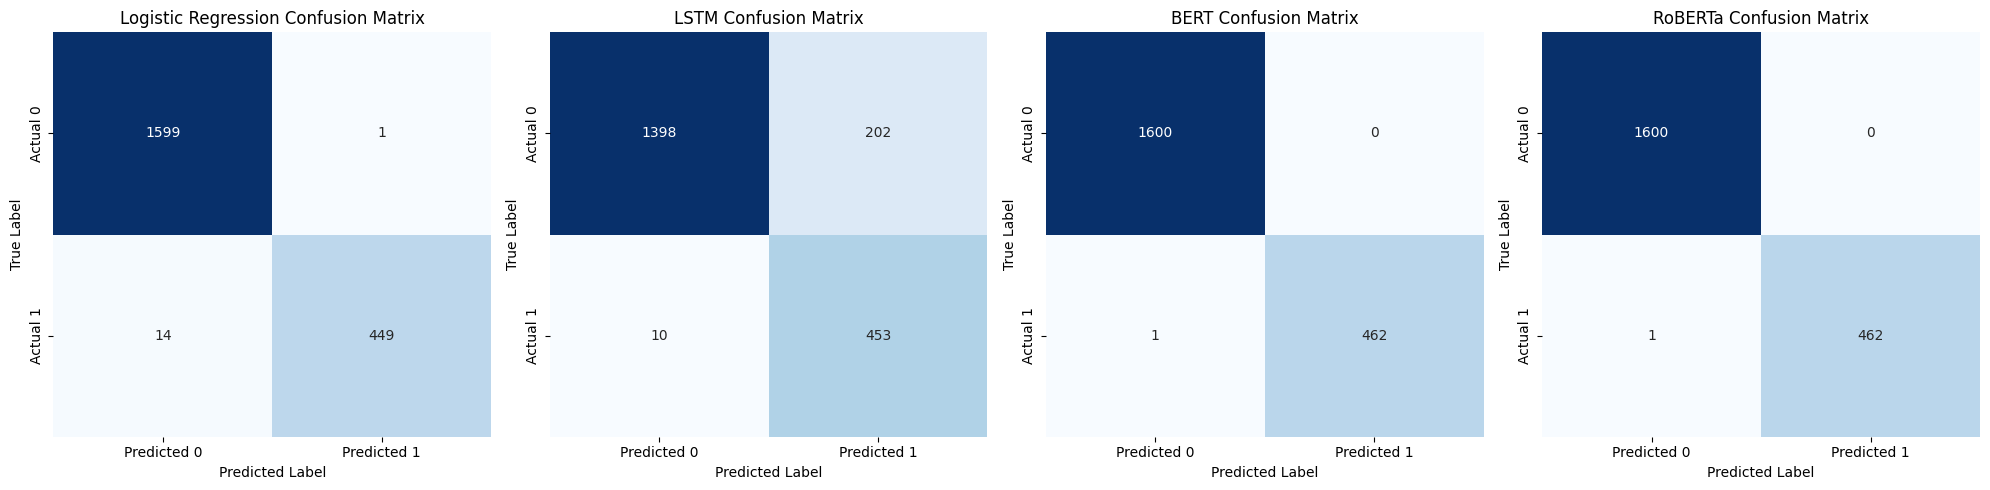

In [99]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recalculate confusion matrices to ensure consistency and use for plotting

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_model.predict(X_test_tfidf))

# LSTM
# y_pred_list and y_test_tensor are already available from LSTM evaluation
# y_pred_binary = (np.array(y_pred_list) > 0.5).astype(int).flatten()
cm_lstm = confusion_matrix(y_test_tensor.cpu().numpy(), y_pred_binary)

# BERT
# y_pred and y_true are already available from BERT evaluation
cm_bert = confusion_matrix(y_true, y_pred)

# RoBERTa
# y_pred_roberta and y_true are already available from RoBERTa evaluation
cm_roberta = confusion_matrix(y_true, y_pred_roberta)

# Define model names and their corresponding confusion matrices
models = {
    'Logistic Regression': cm_lr,
    'LSTM': cm_lstm,
    'BERT': cm_bert,
    'RoBERTa': cm_roberta
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (model_name, cm) in enumerate(models.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=axes[i])
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Confusion Matrix for LSTM Model

|           | Predicted 0 | Predicted 1 |
|-----------|-------------|-------------|
| Actual 0  | 1398        | 202         |
| Actual 1  | 10          | 453         |

- **True Negatives (Actual 0, Predicted 0):** 1398
- **False Positives (Actual 0, Predicted 1):** 202
- **False Negatives (Actual 1, Predicted 0):** 10
- **True Positives (Actual 1, Predicted 1):** 453

### Confusion Matrix for BERT Model

|           | Predicted 0 | Predicted 1 |
|-----------|-------------|-------------|
| Actual 0  | 1600        | 0           |
| Actual 1  | 1           | 462         |

- **True Negatives (Actual 0, Predicted 0):** 1600
- **False Positives (Actual 0, Predicted 1):** 0
- **False Negatives (Actual 1, Predicted 0):** 1
- **True Positives (Actual 1, Predicted 1):** 462

### Confusion Matrix for RoBERTa Model

|           | Predicted 0 | Predicted 1 |
|-----------|-------------|-------------|
| Actual 0  | 1600        | 0           |
| Actual 1  | 1           | 462         |

- **True Negatives (Actual 0, Predicted 0):** 1600
- **False Positives (Actual 0, Predicted 1):** 0
- **False Negatives (Actual 1, Predicted 0):** 1
- **True Positives (Actual 1, Predicted 1):** 462

### Confusion Matrix Comparison Visualization

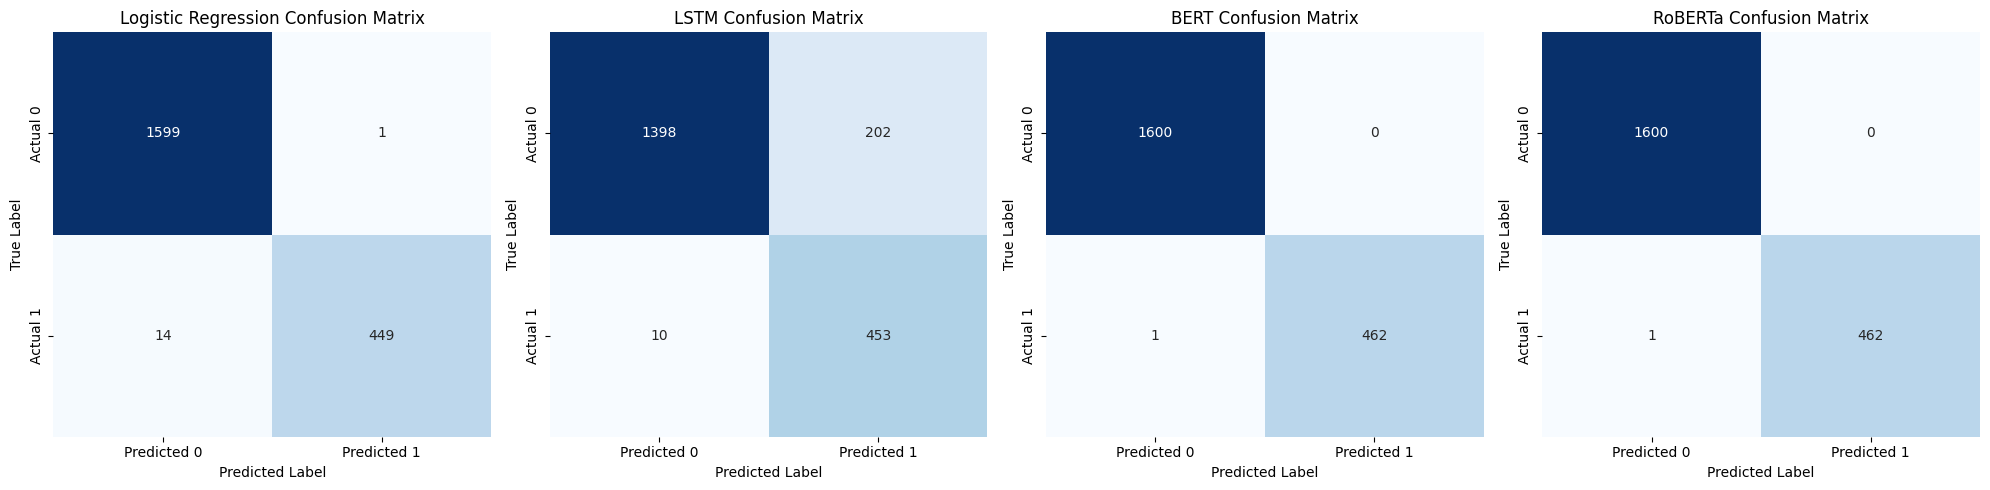

In [98]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recalculate confusion matrices to ensure consistency and use for plotting

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_model.predict(X_test_tfidf))

# LSTM
# y_pred_list and y_test_tensor are already available from LSTM evaluation
# y_pred_binary = (np.array(y_pred_list) > 0.5).astype(int).flatten()
cm_lstm = confusion_matrix(y_test_tensor.cpu().numpy(), y_pred_binary)

# BERT
# y_pred and y_true are already available from BERT evaluation
cm_bert = confusion_matrix(y_true, y_pred)

# RoBERTa
# y_pred_roberta and y_true are already available from RoBERTa evaluation
cm_roberta = confusion_matrix(y_true, y_pred_roberta)

# Define model names and their corresponding confusion matrices
models = {
    'Logistic Regression': cm_lr,
    'LSTM': cm_lstm,
    'BERT': cm_bert,
    'RoBERTa': cm_roberta
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (model_name, cm) in enumerate(models.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=axes[i])
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Real-time Prediction Interface with BERT

Let's create a function that takes a raw text input, preprocesses it using the BERT tokenizer, and then uses our fine-tuned BERT model to make a real-time prediction.

In [100]:
def predict_sentiment_bert(text):
    # Ensure model is in evaluation mode
    model_bert.eval()

    # Tokenize the input text
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt' # Return PyTorch tensors
    )

    # Move inputs to the same device as the model
    inputs = {key: val.to(device) for key, val in inputs.items()}

    # Make prediction
    with torch.no_grad():
        outputs = model_bert(**inputs)
        logits = outputs.logits

    # Get predicted class (0 or 1)
    prediction = torch.argmax(logits, dim=-1).item()

    # Map prediction to labels
    label_map = {0: 'Non-Depressive', 1: 'Depressive'}
    return label_map[prediction]

print("Prediction function for BERT model created.")

Prediction function for BERT model created.


Now, let's test the `predict_sentiment_bert` function with some example texts interactively.

In [101]:
# Example 1: Non-depressive text
text1 = "I am so happy today! The sun is shining and everything is great."
print(f"Text: '{text1}'")
print(f"Predicted Sentiment: {predict_sentiment_bert(text1)}\n")

# Example 2: Depressive text
text2 = "Feeling really down and hopeless lately. Nothing seems to go right."
print(f"Text: '{text2}'")
print(f"Predicted Sentiment: {predict_sentiment_bert(text2)}\n")

# Example 3: Mixed/Neutral text
text3 = "It's a normal day, just working through my tasks."
print(f"Text: '{text3}'")
print(f"Predicted Sentiment: {predict_sentiment_bert(text3)}\n")

# Example 4: Another depressive text
text4 = "Struggling with a lot of anxiety and sadness. Can't seem to shake it off."
print(f"Text: '{text4}'")
print(f"Predicted Sentiment: {predict_sentiment_bert(text4)}\n")

Text: 'I am so happy today! The sun is shining and everything is great.'
Predicted Sentiment: Non-Depressive

Text: 'Feeling really down and hopeless lately. Nothing seems to go right.'
Predicted Sentiment: Non-Depressive

Text: 'It's a normal day, just working through my tasks.'
Predicted Sentiment: Non-Depressive

Text: 'Struggling with a lot of anxiety and sadness. Can't seem to shake it off.'
Predicted Sentiment: Depressive



### Note on full UI/Dashboard:

For a fully interactive, user-friendly UI/dashboard, you would typically use frameworks like Streamlit, Gradio, or build a custom web application. These would allow users to input text directly into a web interface and see predictions in real-time, often deployed on cloud platforms for accessibility.

This demonstration provides the core logic for such an interface within the Colab environment.

In [102]:
!pip install -q gradio

## Gradio Interface for BERT Model

In [108]:
import gradio as gr

# Define the Gradio prediction function
def gradio_predict_sentiment(text):
    if not text.strip(): # Handle empty input
        return "Please enter some text."
    return predict_sentiment_bert(text)

# Create the Gradio Interface
iface = gr.Interface(
    fn=gradio_predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Enter tweet text here..."),
    outputs=gr.Textbox(label="Predicted Sentiment"),
    title="BERT Mental Health Sentiment Analysis",
    description="Enter a tweet to classify its sentiment as Depressive or Non-Depressive using a fine-tuned BERT model."
)

# Launch the interface
print("Launching Gradio interface...")
iface.launch(share=True)

Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1646bc33c22c4fe2f5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Cross-Dataset Validation
Evaluating the model performance on the secondary dataset to test generalization.

In [115]:
# Prepare Secondary Dataset for Cross-Validation
# We will use 'df' which was the original secondary dataset loaded at the start

secondary_texts = df['message to examine'].tolist()
secondary_labels = df['label (depression result)'].tolist()

# Tokenize secondary dataset using the BERT tokenizer
secondary_encodings = tokenize_function(secondary_texts)

class CrossDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

secondary_eval_dataset = CrossDataset(secondary_encodings, secondary_labels)

print(f"Secondary dataset ready for cross-validation. Samples: {len(secondary_eval_dataset)}")

Secondary dataset ready for cross-validation. Samples: 10314


In [118]:
# Re-initialize Trainer to refresh Accelerator state and Evaluate
from transformers import Trainer

# We re-create the trainer instance to fix the AcceleratorState error
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Evaluating Primary-trained BERT on Secondary Dataset...")

# Perform the evaluation on the secondary dataset
cross_val_results = trainer.evaluate(eval_dataset=secondary_eval_dataset, metric_key_prefix="cross_val")

print("\nCross-Dataset Validation Results (on Secondary Data):")
print(cross_val_results)

# Log metrics to W&B for overlapping comparison
wandb.log({"cross_val_accuracy": cross_val_results['cross_val_accuracy'], "cross_val_f1": cross_val_results['cross_val_f1']})

Evaluating Primary-trained BERT on Secondary Dataset...



Cross-Dataset Validation Results (on Secondary Data):
{'cross_val_loss': 0.011770914308726788, 'cross_val_model_preparation_time': 0.0046, 'cross_val_accuracy': 0.9990304440566221, 'cross_val_f1': 0.9978345604157643, 'cross_val_runtime': 82.0308, 'cross_val_samples_per_second': 125.733, 'cross_val_steps_per_second': 7.863}



Performance Comparison Across Datasets:


,Dataset,Accuracy,F1-Score
0,Primary (Internal),0.999515,0.998919
1,Secondary (Cross-Val),0.999030,0.997835


/tmp/ipykernel_17797/935817389.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dataset', y='Accuracy', data=comparison_df, palette='magma')


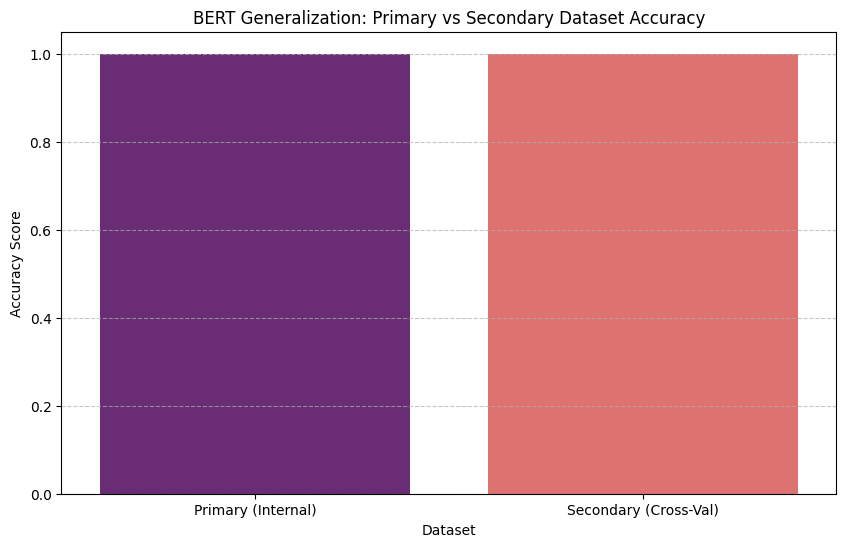

In [119]:
# Compare Metrics: Primary Test Set vs Secondary Cross-Val
if 'cross_val_results' in locals():
    comparison_data = {
        'Dataset': ['Primary (Internal)', 'Secondary (Cross-Val)'],
        'Accuracy': [results['eval_accuracy'], cross_val_results['cross_val_accuracy']],
        'F1-Score': [results['eval_f1'], cross_val_results['cross_val_f1']]
    }

    comparison_df = pd.DataFrame(comparison_data)
    print("\nPerformance Comparison Across Datasets:")
    display(comparison_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Dataset', y='Accuracy', data=comparison_df, palette='magma')
    plt.title('BERT Generalization: Primary vs Secondary Dataset Accuracy')
    plt.ylabel('Accuracy Score')
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Cross-validation results not found. Please run the evaluation cell (f508a172) successfully first.")